# Polynomial Regression

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,SplineTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [4]:
X = 6 * np.random.rand(200, 1)-3
y = 0.8*X**2 + 0.9*X + 2 + np.random.randn(200, 1)


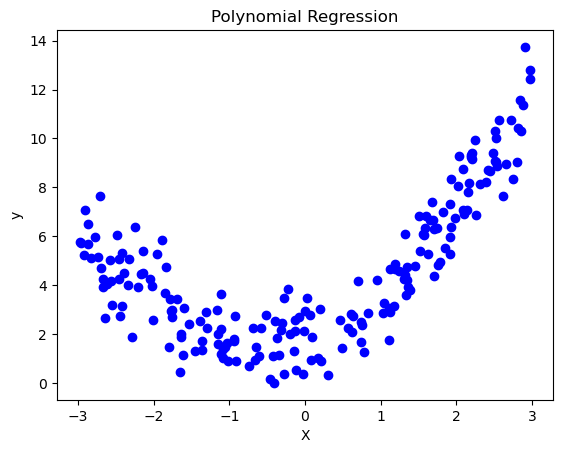

In [5]:
plt.scatter(X,y,color='blue',label='Data Points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression')  
plt.show()

In [6]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(len(x_train), len(x_test))

160 40


In [7]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = lr.predict(x_test)
print('Mean Squared Error:', round(mean_squared_error(y_test, y_pred)*100, 2))
print('R^2 Score:', round(r2_score(y_test, y_pred)*100, 2))   

Mean Squared Error: 608.08
R^2 Score: 30.13


Text(0.5, 1.0, 'Linear Regression Fit')

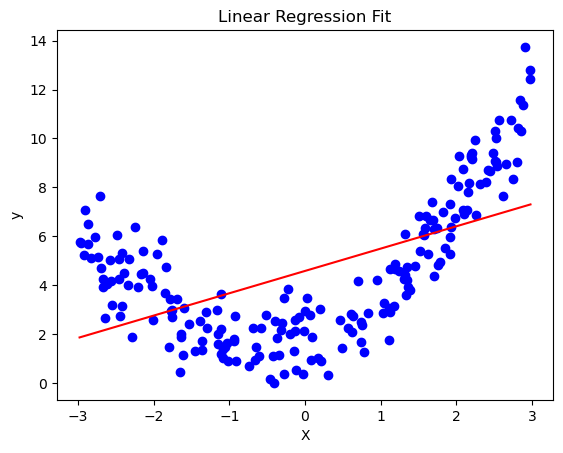

In [9]:
# Visualize the data
plt.scatter(X, y, color='blue', label='Data Points')
# Create a range of X values for plotting the regression line   
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = lr.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', label='Linear Regression Line')

plt.xlabel('X')
plt.ylabel('y')

plt.title('Linear Regression Fit')

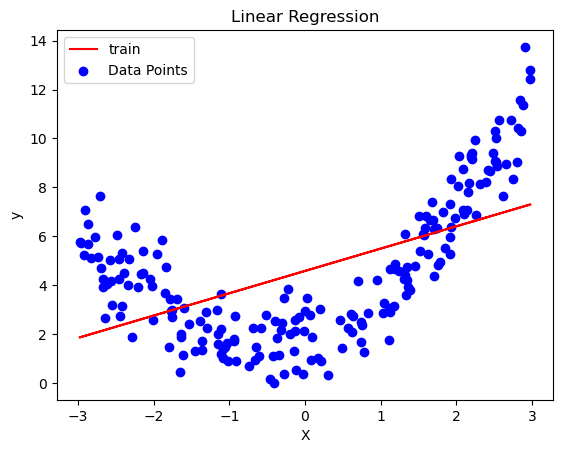

In [10]:
plt.plot(x_train,lr.predict(x_train),'r',label='train')
plt.scatter(X,y,color='blue',label='Data Points')
plt.xlabel('X')
plt.ylabel('y')     
plt.title('Linear Regression')
plt.legend()

## Applying Plolynomial Linear Regressions

In [11]:
poly = PolynomialFeatures(degree=2)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [12]:
print(x_train[0])

[2.38938389]


In [13]:
print(x_train_trans[0])

[1.         2.38938389 5.70915539]


In [14]:
lr1 = LinearRegression()
lr1.fit(x_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred_2 = lr1.predict(x_test_trans)
print('Mean Squared Error:', mean_squared_error(y_test, y_pred_2)*100)
print('R^2 Score:', r2_score(y_test, y_pred_2)*100)

Mean Squared Error: 105.66629450484885
R^2 Score: 87.85917483839997


In [16]:
print(lr1.coef_)

[[0.         0.97273884 0.80218729]]


In [17]:
print(lr1.intercept_)

[1.91636898]


In [18]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr1.predict(x_new_poly)

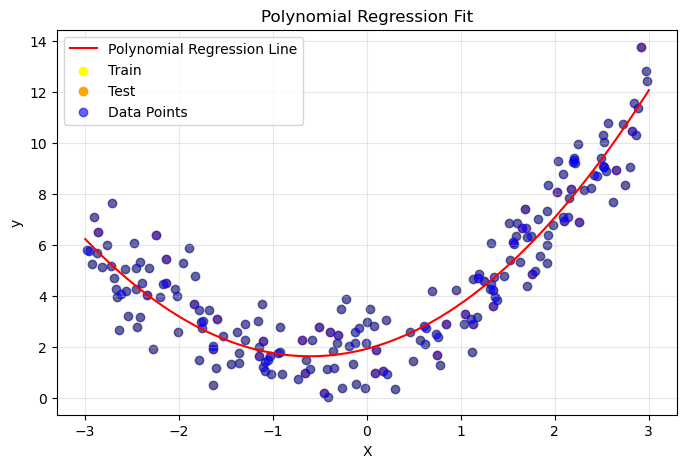

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(x_new, y_new, 'r-', label='Polynomial Regression Line')
plt.scatter(x_train, y_train, color='yellow', label='Train')
plt.scatter(x_test, y_test, color='orange', label='Test')  # yellow can be hard to see
plt.scatter(X, y, color='blue', alpha=0.6, label='Data Points')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [20]:
def polynomial_regression(degree):
    x_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(x_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(x_new)
    plt.plot(x_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

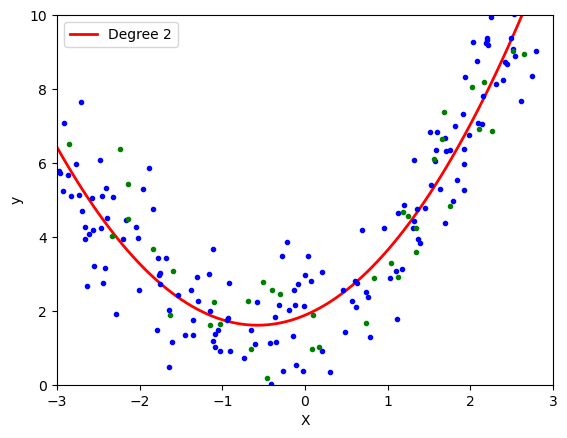

In [21]:
polynomial_regression(2)

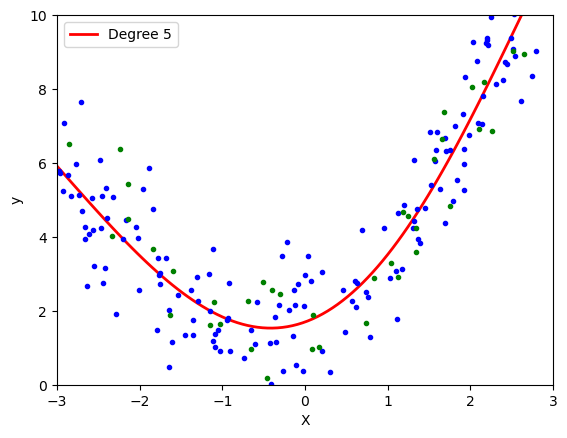

In [22]:
polynomial_regression(5)

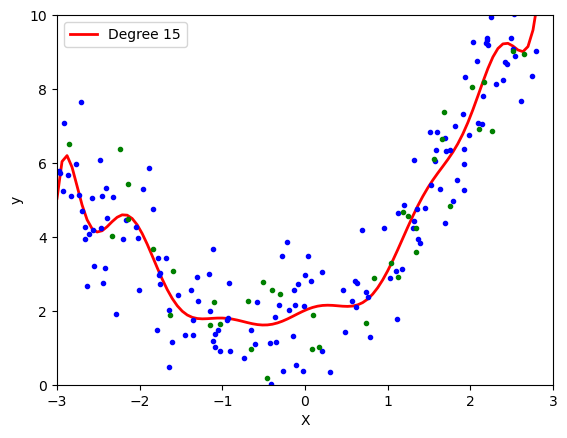

In [23]:
polynomial_regression(15)

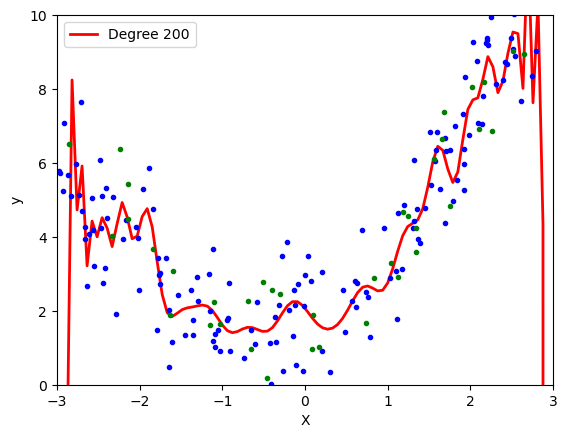

In [24]:
polynomial_regression(200)

In [25]:
poly.powers_

array([[0],
       [1],
       [2]], dtype=int64)

In [26]:
# 3d polynomial regression
x = 7*np.random.rand(100, 1)-2.8
y = 7*np.random.rand(100, 1)-2.8

z = x**2 +y**2+0.2*x+0.1*y*+2+ np.random.randn(100, 1)

In [27]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(x=x.flatten(), y=y.flatten(), z=z.flatten())
fig